# E-Commerce Sales & Customer Behavior Analysis
### UCI Online Retail Dataset | Python EDA | Google Colab

**Goal:** Explore sales performance, product demand, country-level revenue, customer purchasing behavior, cancellations, outliers, time trends, and RFM customer segments.

**Dataset source:** [UCI Machine Learning Repository — Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail)

The original dataset covers transactions from **1 December 2010 to 9 December 2011** and includes invoice, product, quantity, date, price, customer, and country fields.

### How to use this notebook
1. Open this notebook in Google Colab.
2. Run cells from top to bottom.
3. When prompted, upload `Online Retail.xlsx` downloaded from the UCI page.
4. Review the charts and tables generated from your actual data.
5. Replace the business-recommendation template at the end with conclusions supported by your outputs.

**Important:** This notebook does not hard-code analytical results. All reported metrics are calculated from the uploaded dataset.

In [36]:

import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create a folder for all charts
VISUALIZATION_DIR = "/content/All_Visualizations"
os.makedirs(VISUALIZATION_DIR, exist_ok=True)

# Automatically save each Matplotlib/Seaborn figure when it is shown
_original_show = plt.show
_chart_counter = {"count": 0}

def save_and_show(*args, **kwargs):
    figures = list(plt.get_fignums())

    for fig_num in figures:
        fig = plt.figure(fig_num)
        _chart_counter["count"] += 1

        filename = f"visualization_{_chart_counter['count']:02d}.png"
        fig.savefig(
            os.path.join(VISUALIZATION_DIR, filename),
            dpi=200,
            bbox_inches="tight"
        )

    return _original_show(*args, **kwargs)

plt.show = save_and_show

print("Automatic chart saving is ready!")


Automatic chart saving is ready!


## 1. Import libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 50)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Excel dataset
Upload the original `Online Retail.xlsx` file when prompted.

In [38]:
from google.colab import files

uploaded = files.upload()

file_name = next(iter(uploaded))
df_original = pd.read_excel(file_name)

print(f"Loaded file: {file_name}")
print(f"Rows: {df_original.shape[0]:,} | Columns: {df_original.shape[1]}")
display(df_original.head())

Saving Online Retail Data Set.xlsx.xlsx to Online Retail Data Set.xlsx (1).xlsx
Loaded file: Online Retail Data Set.xlsx (1).xlsx
Rows: 541,909 | Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Understand the data

In [39]:
print("Column names:")
print(df_original.columns.tolist())

print("\nData types and non-null counts:")
df_original.info()

print("\nDescriptive statistics:")
display(df_original.describe(include="all").T)

print("\nFirst and last transaction dates (raw values):")
print(df_original["InvoiceDate"].min(), "to", df_original["InvoiceDate"].max())

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Descriptive statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN



First and last transaction dates (raw values):
2010-12-01 08:26:00 to 2011-12-09 12:50:00


## 4. Missing-value and duplicate analysis

,Missing_Count,Missing_Percent
CustomerID,135080,24.93
Description,1454,0.27
StockCode,0,0.00
InvoiceNo,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


Exact duplicate rows: 5,268


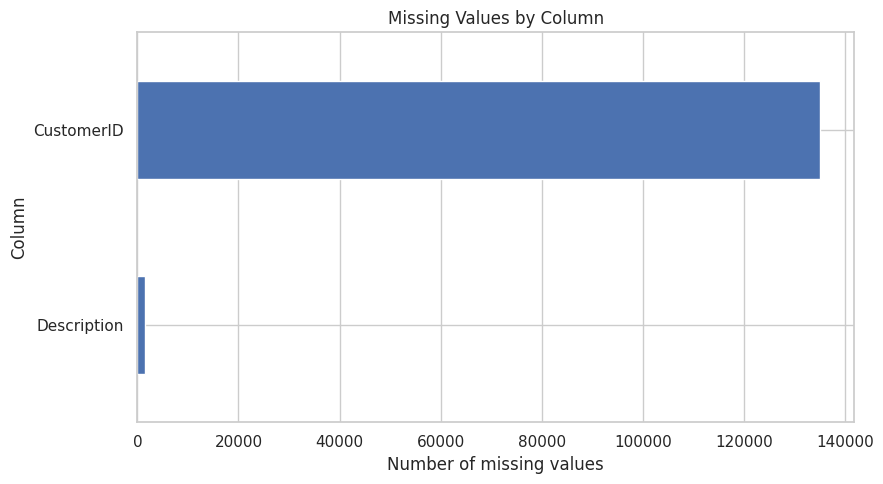

In [40]:
missing_summary = pd.DataFrame({
    "Missing_Count": df_original.isna().sum(),
    "Missing_Percent": (df_original.isna().mean() * 100).round(2)
}).sort_values("Missing_Count", ascending=False)

display(missing_summary)

duplicate_count = df_original.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_count:,}")

missing_nonzero = missing_summary[missing_summary["Missing_Count"] > 0]
if not missing_nonzero.empty:
    ax = missing_nonzero["Missing_Count"].sort_values().plot(
        kind="barh", figsize=(9, 5), title="Missing Values by Column"
    )
    ax.set_xlabel("Number of missing values")
    ax.set_ylabel("Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")

## 5. Data cleaning and feature engineering
We retain an untouched copy (`df_original`) and create a working copy. Exact duplicates are removed. Missing customer IDs are not filled with invented IDs. Cancellation invoices are flagged for separate analysis.

In [41]:
df = df_original.copy()
df = df.drop_duplicates().copy()

# Normalize important data types
df["InvoiceNo"] = df["InvoiceNo"].astype("string").str.strip()
df["StockCode"] = df["StockCode"].astype("string").str.strip()
df["Description"] = df["Description"].astype("string").str.strip()
df["Country"] = df["Country"].astype("string").str.strip()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")

# Cancellation flag: UCI documentation says invoice numbers beginning with C indicate cancellation.
df["IsCancelled"] = df["InvoiceNo"].str.upper().str.startswith("C", na=False)

# Line-level amount; negative quantities remain negative and are not silently removed here.
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print(f"Rows in original data: {len(df_original):,}")
print(f"Rows after exact duplicate removal: {len(df):,}")
print(f"Cancelled invoice lines: {df['IsCancelled'].sum():,}")
print(f"Rows with missing CustomerID: {df['CustomerID'].isna().sum():,}")
display(df.head())

Rows in original data: 541,909
Rows after exact duplicate removal: 536,641
Cancelled invoice lines: 9,251
Rows with missing CustomerID: 135,037


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34


## 6. Define the regular-sales analysis population
For product, revenue, and RFM analysis, this notebook uses rows that are not flagged as cancelled, have valid invoice dates, positive quantities and positive unit prices. This is a transparent analysis rule, not a claim that every excluded row is erroneous. Returns/cancellations are analyzed separately below.

In [42]:
valid_base = (
    df["InvoiceDate"].notna()
    & df["InvoiceNo"].notna()
    & df["StockCode"].notna()
    & df["Description"].notna()
    & df["Quantity"].notna()
    & df["UnitPrice"].notna()
)

sales = df.loc[
    valid_base
    & (~df["IsCancelled"])
    & (df["Quantity"] > 0)
    & (df["UnitPrice"] > 0)
].copy()

sales["Revenue"] = sales["Quantity"] * sales["UnitPrice"]
sales["YearMonth"] = sales["InvoiceDate"].dt.to_period("M").astype(str)
sales["Weekday"] = sales["InvoiceDate"].dt.day_name()
sales["Hour"] = sales["InvoiceDate"].dt.hour
sales["Date"] = sales["InvoiceDate"].dt.date

print(f"Rows in regular-sales analysis: {len(sales):,}")
print(f"Unique invoices: {sales['InvoiceNo'].nunique():,}")
print(f"Unique products (StockCode): {sales['StockCode'].nunique():,}")
print(f"Customers with IDs: {sales['CustomerID'].nunique():,}")
print(f"Gross line revenue in this filtered population: £{sales['Revenue'].sum():,.2f}")

Rows in regular-sales analysis: 524,878
Unique invoices: 19,960
Unique products (StockCode): 3,922
Customers with IDs: 4,338
Gross line revenue in this filtered population: £10,642,110.80


## 7. KPI summary

In [43]:
order_revenue = sales.groupby("InvoiceNo")["Revenue"].sum()
kpis = pd.Series({
    "Regular sales rows": len(sales),
    "Unique invoices/orders": sales["InvoiceNo"].nunique(),
    "Unique products": sales["StockCode"].nunique(),
    "Identified customers": sales["CustomerID"].nunique(),
    "Total quantity sold": sales["Quantity"].sum(),
    "Gross revenue (£)": sales["Revenue"].sum(),
    "Average order value (£)": order_revenue.mean(),
    "Median order value (£)": order_revenue.median()
}, name="Value")

display(kpis.to_frame())

,Value
Regular sales rows,5.248780e+05
Unique invoices/orders,1.996000e+04
Unique products,3.922000e+03
Identified customers,4.338000e+03
Total quantity sold,5.572420e+06
Gross revenue (£),1.064211e+07
Average order value (£),5.331719e+02
Median order value (£),3.033000e+02


## 8. Univariate analysis: quantities and prices

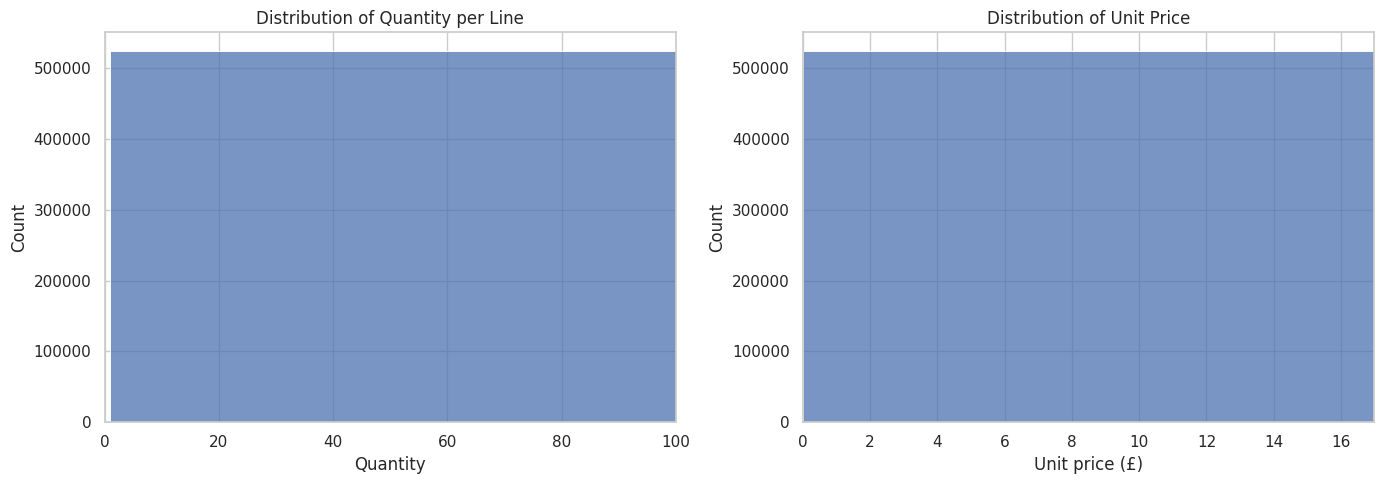

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(sales["Quantity"], bins=50, ax=axes[0])
axes[0].set_title("Distribution of Quantity per Line")
axes[0].set_xlabel("Quantity")
axes[0].set_xlim(0, sales["Quantity"].quantile(0.99))

sns.histplot(sales["UnitPrice"], bins=50, ax=axes[1])
axes[1].set_title("Distribution of Unit Price")
axes[1].set_xlabel("Unit price (£)")
axes[1].set_xlim(0, sales["UnitPrice"].quantile(0.99))

plt.tight_layout()
plt.show()

## 9. Top 10 products by revenue — horizontal bar chart

,Revenue (£)
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


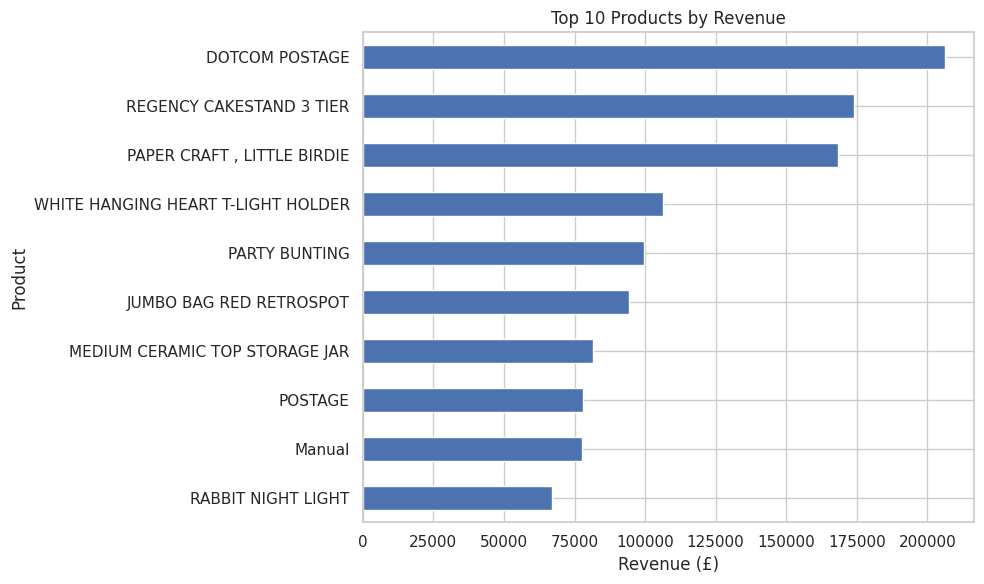

In [45]:
top_products_revenue = (
    sales.groupby("Description")["Revenue"]
    .sum()
    .nlargest(10)
    .sort_values()
)

display(top_products_revenue.sort_values(ascending=False).to_frame("Revenue (£)"))

top_products_revenue.plot(kind="barh", figsize=(10, 6))
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## 10. Top 10 products by quantity sold

,Quantity sold
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


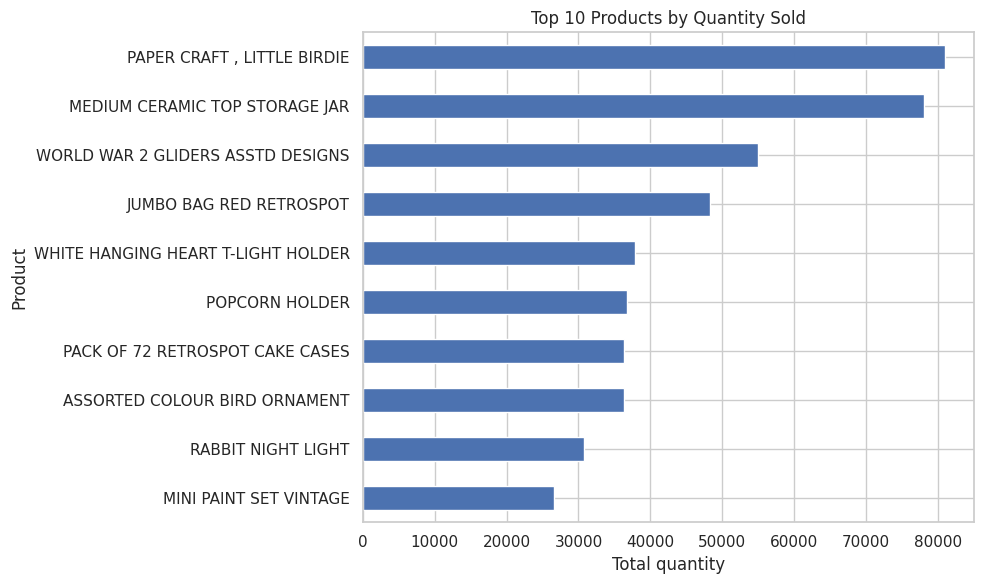

In [46]:
top_products_quantity = (
    sales.groupby("Description")["Quantity"]
    .sum()
    .nlargest(10)
    .sort_values()
)

display(top_products_quantity.sort_values(ascending=False).to_frame("Quantity sold"))

top_products_quantity.plot(kind="barh", figsize=(10, 6))
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total quantity")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## 11. Revenue by country — bar chart

,Revenue (£)
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


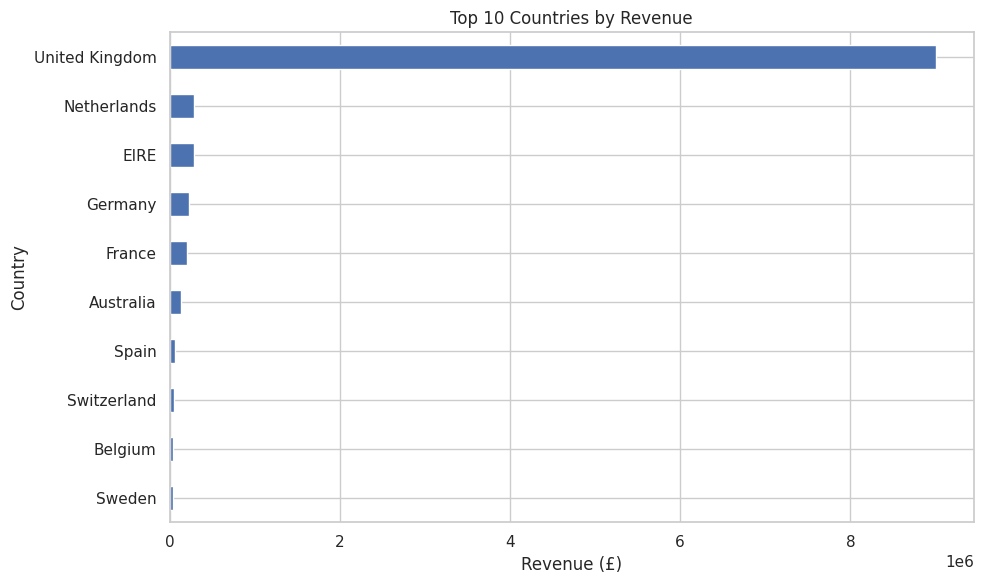

In [47]:
country_revenue = sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
display(country_revenue.head(10).to_frame("Revenue (£)"))

country_revenue.head(10).sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## 12. Revenue contribution by country — pie chart
The pie chart shows the top five countries separately and combines all remaining countries into `Others` so it remains readable.

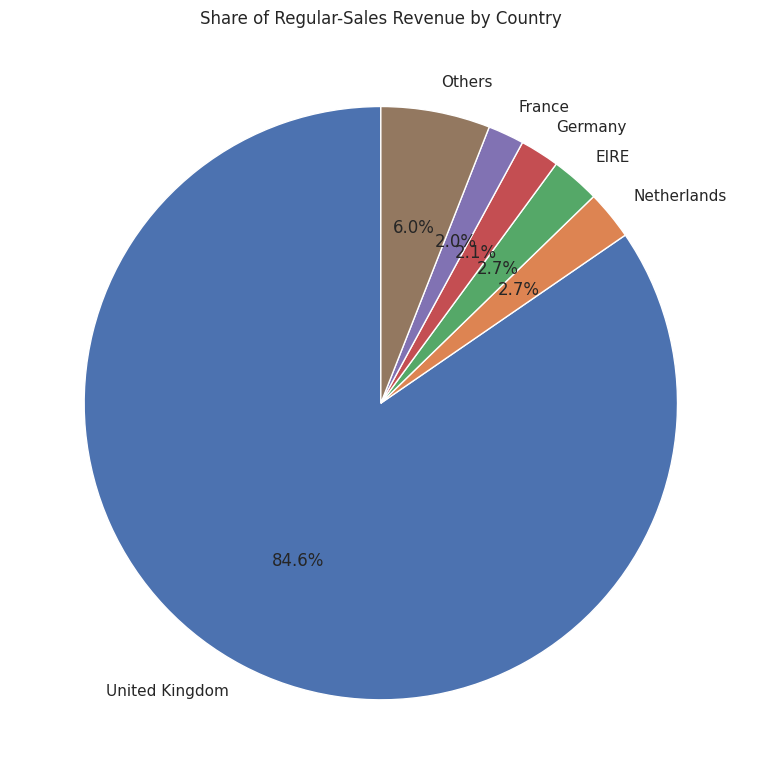

In [48]:
top5_countries = country_revenue.head(5)
others_revenue = country_revenue.iloc[5:].sum()
pie_values = pd.concat([top5_countries, pd.Series({"Others": others_revenue})])

plt.figure(figsize=(8, 8))
plt.pie(
    pie_values.values,
    labels=pie_values.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Share of Regular-Sales Revenue by Country")
plt.tight_layout()
plt.show()

## 13. Monthly revenue trend — line chart

,Revenue (£)
InvoiceDate,
2010-12-01,821452.730
2011-01-01,689811.610
2011-02-01,522545.560
2011-03-01,716215.260
2011-04-01,536968.491
2011-05-01,769296.610
2011-06-01,760547.010
2011-07-01,718076.121
2011-08-01,757841.380


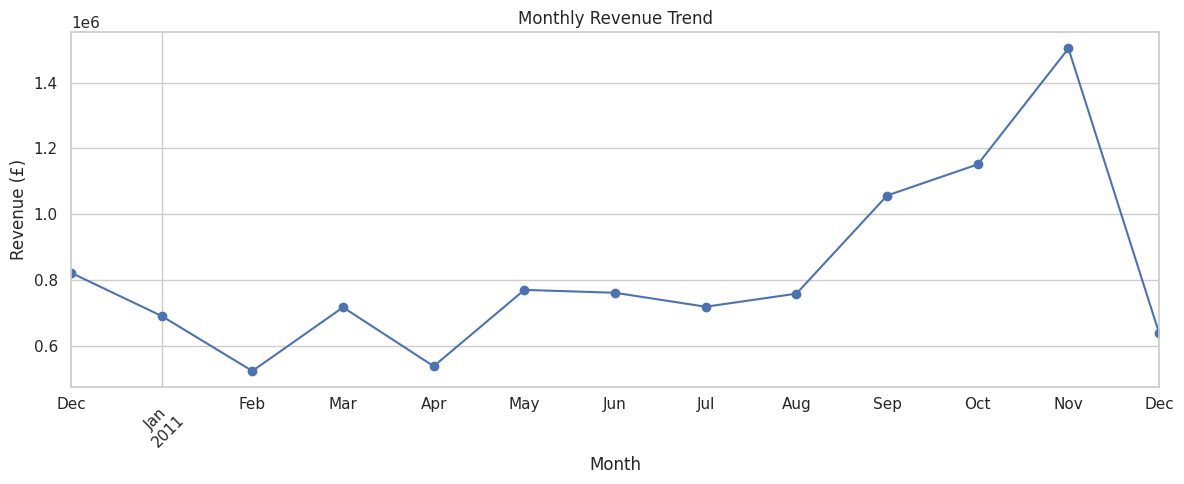

Note: the first and last months may be partial because the dataset covers a limited date range.


In [49]:
monthly_revenue = (
    sales.set_index("InvoiceDate")["Revenue"]
    .resample("MS")
    .sum()
)

display(monthly_revenue.to_frame("Revenue (£)"))

monthly_revenue.plot(marker="o", figsize=(12, 5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Note: the first and last months may be partial because the dataset covers a limited date range.")

## 14. Orders by weekday

,Unique invoices
Weekday,
Monday,3126
Tuesday,3554
Wednesday,3690
Thursday,4246
Friday,3140
Saturday,0
Sunday,2204


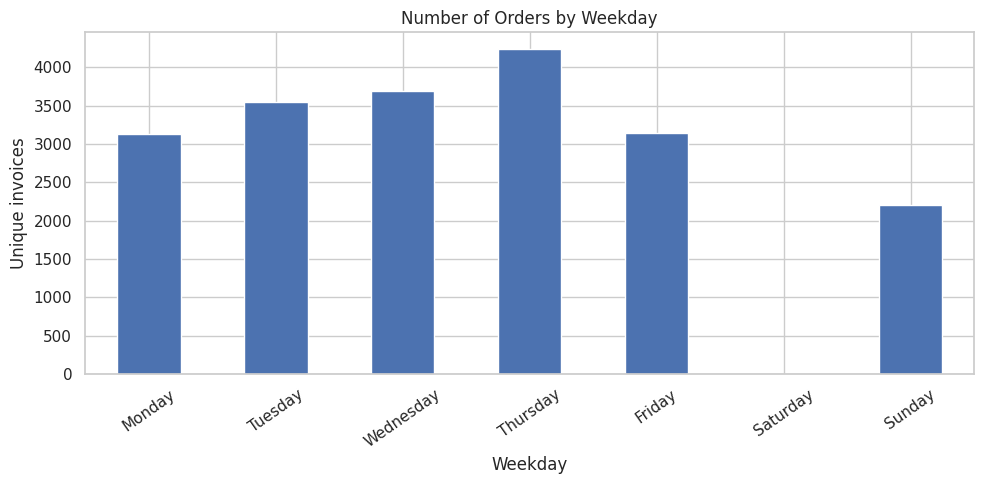

In [50]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_orders = (
    sales.groupby("Weekday")["InvoiceNo"]
    .nunique()
    .reindex(weekday_order, fill_value=0)
)

display(weekday_orders.to_frame("Unique invoices"))

weekday_orders.plot(kind="bar", figsize=(10, 5))
plt.title("Number of Orders by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Unique invoices")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

## 15. Hour-of-day pattern

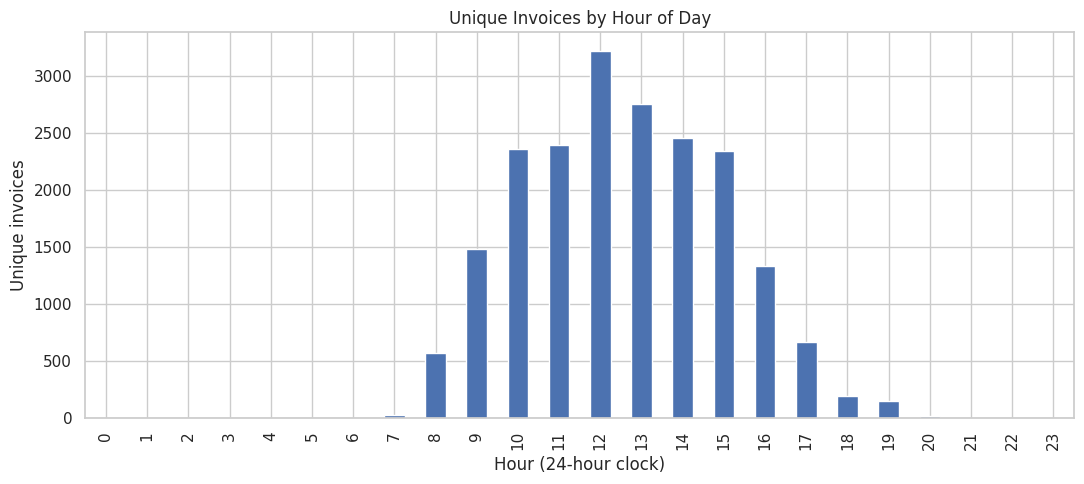

In [51]:
hour_orders = sales.groupby("Hour")["InvoiceNo"].nunique().reindex(range(24), fill_value=0)

hour_orders.plot(kind="bar", figsize=(11, 5))
plt.title("Unique Invoices by Hour of Day")
plt.xlabel("Hour (24-hour clock)")
plt.ylabel("Unique invoices")
plt.tight_layout()
plt.show()

## 16. Average order value
Average order value (AOV) is the mean of invoice-level revenue in the regular-sales population. The median is also shown because order values can be skewed.

Number of invoices: 19,960
Average order value: £533.17
Median order value: £303.30


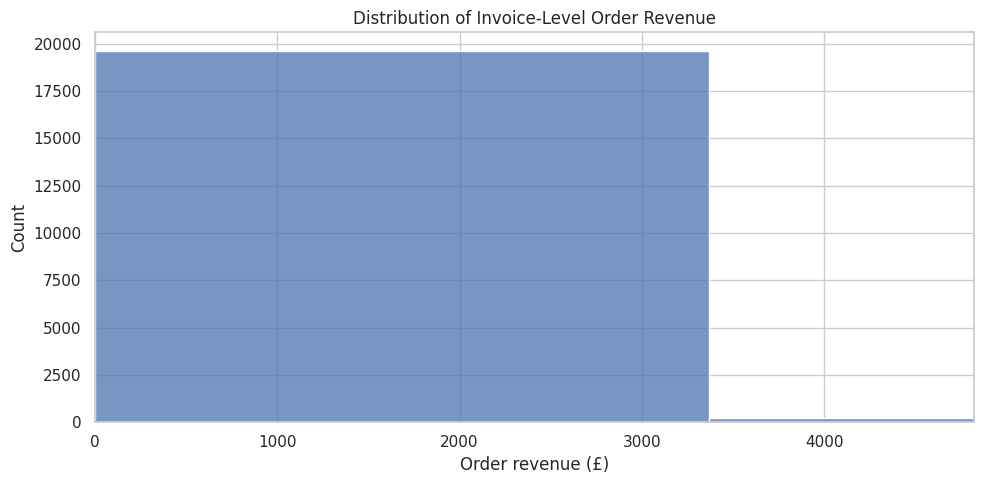

In [52]:
order_summary = sales.groupby("InvoiceNo").agg(
    OrderRevenue=("Revenue", "sum"),
    OrderQuantity=("Quantity", "sum"),
    OrderDate=("InvoiceDate", "min")
)

print(f"Number of invoices: {len(order_summary):,}")
print(f"Average order value: £{order_summary['OrderRevenue'].mean():,.2f}")
print(f"Median order value: £{order_summary['OrderRevenue'].median():,.2f}")

sns.histplot(order_summary["OrderRevenue"], bins=50)
plt.title("Distribution of Invoice-Level Order Revenue")
plt.xlabel("Order revenue (£)")
plt.xlim(0, order_summary["OrderRevenue"].quantile(0.99))
plt.tight_layout()
plt.show()

## 17. Customer value: top 10 identified customers

,Revenue (£)
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


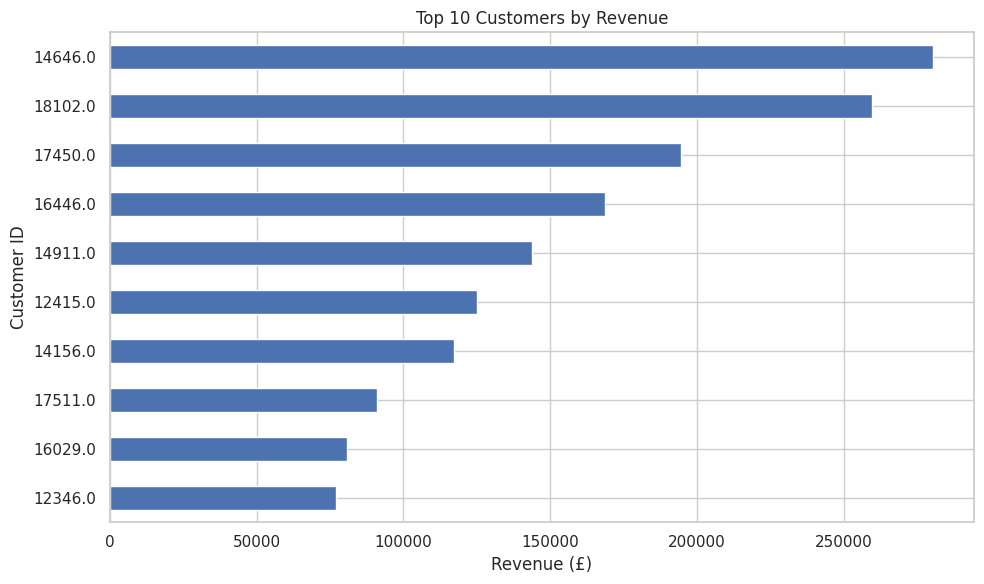

In [53]:
customer_revenue = (
    sales.dropna(subset=["CustomerID"])
    .groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

display(customer_revenue.head(10).to_frame("Revenue (£)"))

customer_revenue.head(10).sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

## 18. Outlier analysis with box plots
Box plots help identify extreme values; an outlier is not automatically an error. Whiskers are shown on the central 98% display range for readability, without deleting those rows from `sales`.

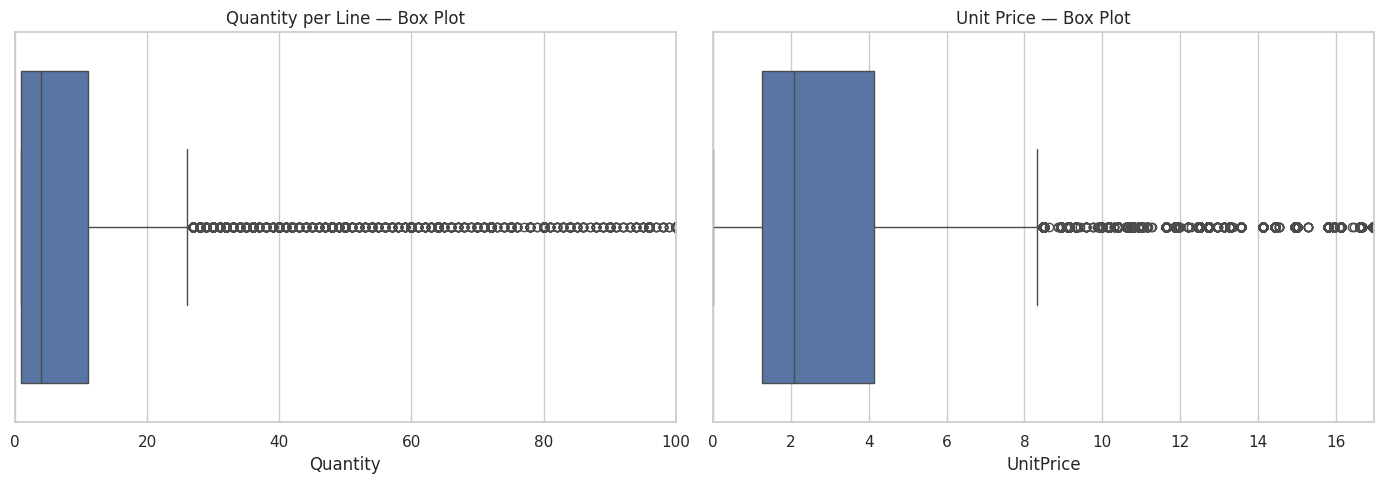

Quantity quantiles:


,Quantity
0.500,4.0
0.900,24.0
0.950,30.0
0.990,100.0
0.999,456.0


Unit price quantiles:


,UnitPrice (£)
0.500,2.0800
0.900,7.9500
0.950,9.9500
0.990,16.9800
0.999,165.0246


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=sales["Quantity"], ax=axes[0])
axes[0].set_title("Quantity per Line — Box Plot")
axes[0].set_xlim(0, sales["Quantity"].quantile(0.99))

sns.boxplot(x=sales["UnitPrice"], ax=axes[1])
axes[1].set_title("Unit Price — Box Plot")
axes[1].set_xlim(0, sales["UnitPrice"].quantile(0.99))

plt.tight_layout()
plt.show()

print("Quantity quantiles:")
display(sales["Quantity"].quantile([0.5, 0.9, 0.95, 0.99, 0.999]).to_frame("Quantity"))
print("Unit price quantiles:")
display(sales["UnitPrice"].quantile([0.5, 0.9, 0.95, 0.99, 0.999]).to_frame("UnitPrice (£)"))

## 19. Price versus quantity — scatter plot and correlation
A sample is used for plotting performance. Pearson correlation describes a linear association; it does not prove that price causes quantity changes.

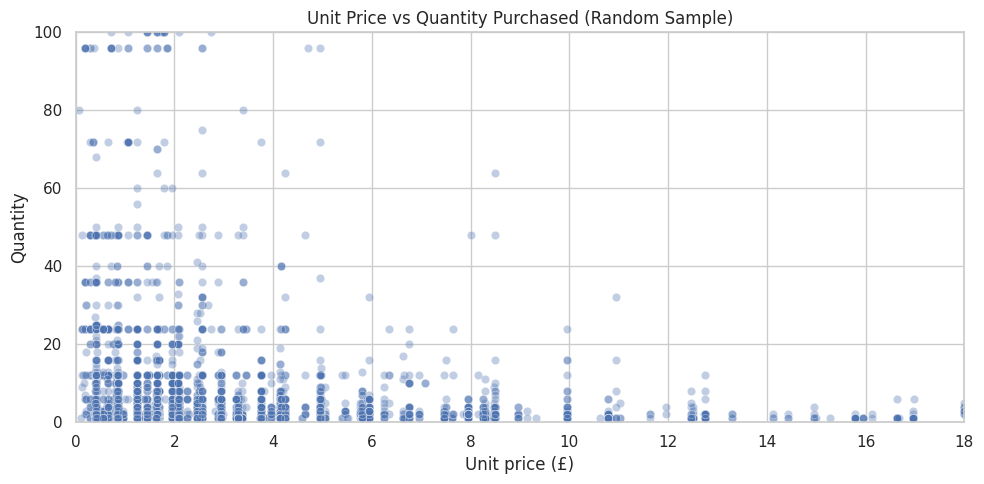

Pearson correlation: -0.004
Spearman correlation: -0.409


In [55]:
sample = sales.sample(n=min(5000, len(sales)), random_state=42)

sns.scatterplot(data=sample, x="UnitPrice", y="Quantity", alpha=0.35)
plt.title("Unit Price vs Quantity Purchased (Random Sample)")
plt.xlabel("Unit price (£)")
plt.ylabel("Quantity")
plt.xlim(0, sample["UnitPrice"].quantile(0.99))
plt.ylim(0, sample["Quantity"].quantile(0.99))
plt.tight_layout()
plt.show()

pearson_corr = sales["UnitPrice"].corr(sales["Quantity"], method="pearson")
spearman_corr = sales["UnitPrice"].corr(sales["Quantity"], method="spearman")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")

## 20. Correlation heatmap

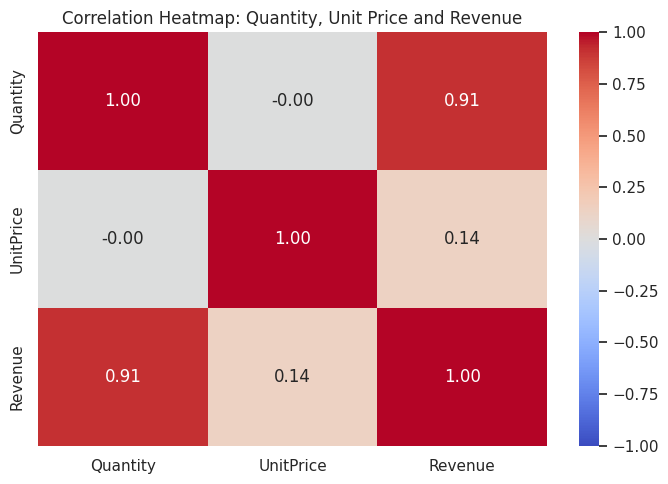

In [56]:
numeric_columns = ["Quantity", "UnitPrice", "Revenue"]
corr = sales[numeric_columns].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap: Quantity, Unit Price and Revenue")
plt.tight_layout()
plt.show()

## 21. Cancellation and return analysis
Cancellation invoice IDs begin with `C`. Negative quantities can also indicate returns/credit adjustments. We calculate cancellation rates at both line and invoice levels because they answer different questions.

Cancelled line percentage: 1.72%
Cancelled invoice percentage: 14.81%
Rows with negative quantity: 10,587 (1.97%)


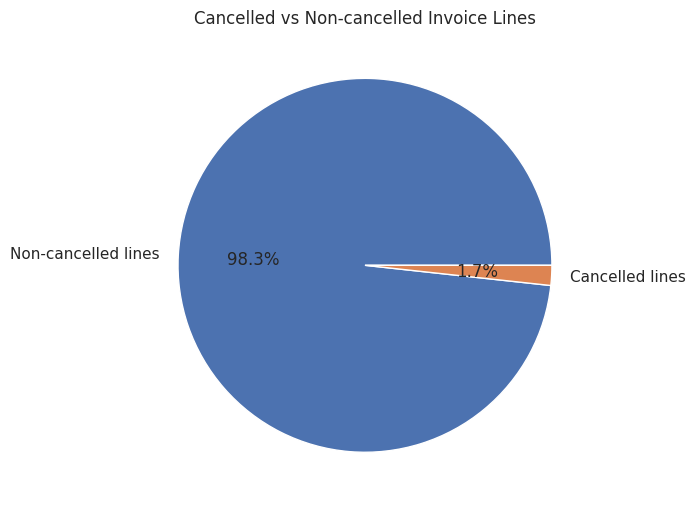

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,InvoiceDate
141,C536379,D,Discount,-1,27.50,2010-12-01 09:41:00
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,4.65,2010-12-01 09:49:00
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.65,2010-12-01 10:24:00
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29,2010-12-01 10:24:00
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29,2010-12-01 10:24:00
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,0.29,2010-12-01 10:24:00
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,3.45,2010-12-01 10:24:00
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,1.65,2010-12-01 10:24:00
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,1.65,2010-12-01 10:24:00
939,C536506,22960,JAM MAKING SET WITH JARS,-6,4.25,2010-12-01 12:38:00


In [57]:
# Cancellation line rate among rows with invoice numbers
invoice_rows = df[df["InvoiceNo"].notna()].copy()
cancelled_line_rate = invoice_rows["IsCancelled"].mean() * 100

# Unique invoices and cancelled invoice IDs
invoice_flags = (
    invoice_rows.groupby("InvoiceNo")["IsCancelled"]
    .any()
)
cancelled_invoice_rate = invoice_flags.mean() * 100

negative_quantity_rows = (df["Quantity"] < 0).sum()
negative_quantity_rate = (df["Quantity"] < 0).mean() * 100

print(f"Cancelled line percentage: {cancelled_line_rate:.2f}%")
print(f"Cancelled invoice percentage: {cancelled_invoice_rate:.2f}%")
print(f"Rows with negative quantity: {negative_quantity_rows:,} ({negative_quantity_rate:.2f}%)")

cancel_chart = pd.Series({
    "Non-cancelled lines": int((~invoice_rows["IsCancelled"]).sum()),
    "Cancelled lines": int(invoice_rows["IsCancelled"].sum())
})
cancel_chart.plot(kind="pie", autopct="%1.1f%%", figsize=(7, 7), ylabel="")
plt.title("Cancelled vs Non-cancelled Invoice Lines")
plt.tight_layout()
plt.show()

# Examine negative quantity rows separately
display(df.loc[df["Quantity"] < 0, ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "InvoiceDate"]].head(10))

## 22. RFM customer segmentation
RFM means **Recency, Frequency, Monetary value**:
- **Recency:** days since the customer's most recent purchase (lower is better).
- **Frequency:** number of distinct invoices (higher is generally better).
- **Monetary:** total revenue in the regular-sales population (higher is generally better).

The reference date is set to one day after the latest invoice timestamp in the filtered sales dataset, making the result reproducible for this dataset. Customers without a CustomerID cannot be assigned to individual RFM segments.

In [58]:
rfm_source = sales.dropna(subset=["CustomerID"]).copy()

if rfm_source.empty:
    raise ValueError("No identified customers are available for RFM analysis.")

reference_date = rfm_source["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)

rfm = rfm_source.groupby("CustomerID").agg(
    LastPurchase=("InvoiceDate", "max"),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
)

rfm["Recency"] = (reference_date - rfm["LastPurchase"].dt.normalize()).dt.days
rfm = rfm[["Recency", "Frequency", "Monetary"]]

print("RFM reference date:", reference_date.date())
display(rfm.head())
display(rfm.describe().T)

RFM reference date: 2011-12-10


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,3,7,4310.00
12348.0,76,4,1797.24
12349.0,19,1,1757.55
12350.0,311,1,334.40


,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,93.059474,100.012264,1.00,18.0000,51.00,142.7500,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.0000,2.00,5.0000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75,306.4825,668.57,1660.5975,280206.02


## 23. RFM scoring
Each metric is scored from 1 to 5 using quintiles. For Recency, lower values receive higher scores; for Frequency and Monetary, higher values receive higher scores. Duplicate quantile boundaries can occur, so the code uses rank-based quintiles to remain robust.

In [59]:
# Rank first to handle repeated values and avoid duplicate qcut edges.
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first", ascending=True),
    5, labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first", ascending=True),
    5, labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first", ascending=True),
    5, labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

def assign_segment(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Best Customers"
    elif r >= 3 and f >= 3:
        return "Loyal / Active"
    elif r >= 4 and f <= 2:
        return "Recent Customers"
    elif r <= 2 and f >= 3:
        return "At-Risk Valuable"
    elif r <= 2 and f <= 2:
        return "Hibernating / Low Activity"
    else:
        return "Potential / Developing"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)

display(rfm.sort_values("Monetary", ascending=False).head(15))

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
14646.0,2,73,280206.02,5,5,5,555,Best Customers
18102.0,1,60,259657.30,5,5,5,555,Best Customers
17450.0,9,46,194390.79,5,5,5,555,Best Customers
16446.0,1,2,168472.50,5,3,5,535,Loyal / Active
14911.0,2,201,143711.17,5,5,5,555,Best Customers
12415.0,25,21,124914.53,4,5,5,455,Best Customers
14156.0,10,55,117210.08,5,5,5,555,Best Customers
17511.0,3,31,91062.38,5,5,5,555,Best Customers
16029.0,39,63,80850.84,3,5,5,355,Loyal / Active


## 24. RFM segment charts and summary

,Customers
Segment,
Hibernating / Low Activity,1072
Loyal / Active,999
Best Customers,941
At-Risk Valuable,663
Potential / Developing,353
Recent Customers,310


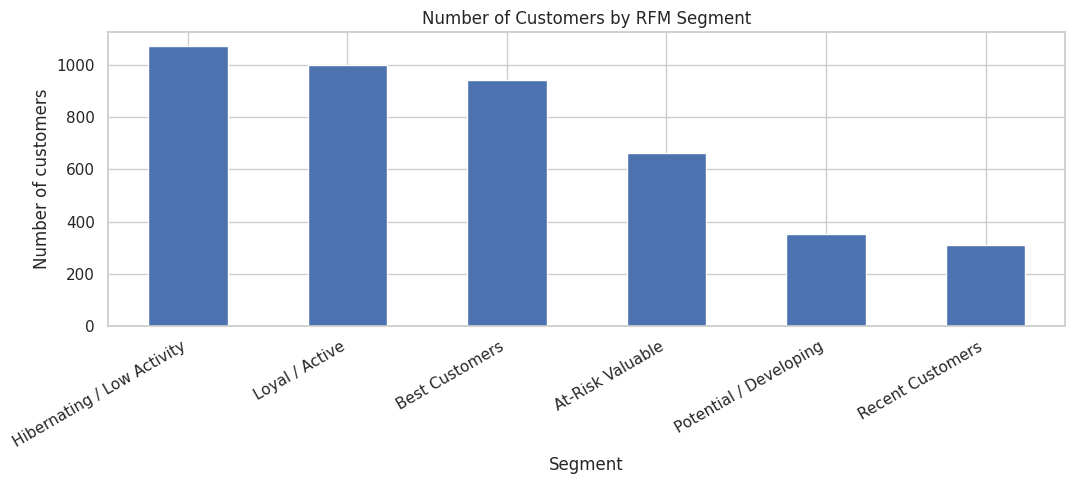

,Monetary revenue (£)
Segment,
Best Customers,5741913.580
Loyal / Active,1493228.741
At-Risk Valuable,827416.571
Hibernating / Low Activity,523208.532
Potential / Developing,165684.350
Recent Customers,135757.120


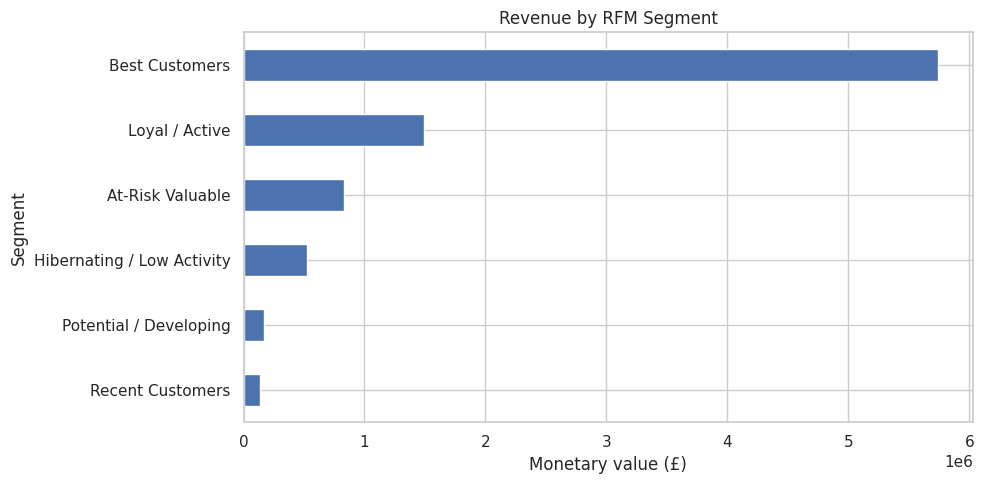

In [60]:
segment_counts = rfm["Segment"].value_counts()
display(segment_counts.to_frame("Customers"))

segment_counts.plot(kind="bar", figsize=(11, 5))
plt.title("Number of Customers by RFM Segment")
plt.xlabel("Segment")
plt.ylabel("Number of customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)
display(segment_revenue.to_frame("Monetary revenue (£)"))

segment_revenue.sort_values().plot(kind="barh", figsize=(10, 5))
plt.title("Revenue by RFM Segment")
plt.xlabel("Monetary value (£)")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

## 25. Product demand trend: compare first and second halves of observed months
This is a simple exploratory comparison, not a forecast. Only products appearing in both periods are compared, and periods are based on the available dataset range.

In [61]:
monthly_product_qty = (
    sales.assign(MonthStart=sales["InvoiceDate"].dt.to_period("M").dt.to_timestamp())
    .groupby(["MonthStart", "Description"])["Quantity"]
    .sum()
    .reset_index()
)

if not monthly_product_qty.empty:
    months = sorted(monthly_product_qty["MonthStart"].unique())
    midpoint = len(months) // 2
    first_months = months[:midpoint]
    second_months = months[midpoint:]

    first_qty = (
        monthly_product_qty[monthly_product_qty["MonthStart"].isin(first_months)]
        .groupby("Description")["Quantity"].sum()
    )
    second_qty = (
        monthly_product_qty[monthly_product_qty["MonthStart"].isin(second_months)]
        .groupby("Description")["Quantity"].sum()
    )

    demand_compare = pd.concat(
        [first_qty.rename("First_Period_Quantity"),
         second_qty.rename("Second_Period_Quantity")],
        axis=1
    ).fillna(0)

    demand_compare = demand_compare[
        (demand_compare["First_Period_Quantity"] > 0)
        & (demand_compare["Second_Period_Quantity"] > 0)
    ]

    demand_compare["Change"] = (
        demand_compare["Second_Period_Quantity"]
        - demand_compare["First_Period_Quantity"]
    )
    demand_compare = demand_compare.sort_values("Change", ascending=False)

    print("Largest increases (among products present in both periods):")
    display(demand_compare.head(10))

    print("Largest decreases (among products present in both periods):")
    display(demand_compare.tail(10).sort_values("Change"))
else:
    print("No product-month data available.")

Largest increases (among products present in both periods):


,First_Period_Quantity,Second_Period_Quantity,Change
Description,,,
RABBIT NIGHT LIGHT,1130.0,29609.0,28479.0
PAPER CHAIN KIT 50'S CHRISTMAS,2599.0,16730.0,14131.0
60 CAKE CASES VINTAGE CHRISTMAS,1384.0,14648.0,13264.0
WOODEN STAR CHRISTMAS SCANDINAVIAN,162.0,10298.0,10136.0
WOODEN HEART CHRISTMAS SCANDINAVIAN,385.0,10223.0,9838.0
JUMBO BAG RED RETROSPOT,19335.0,29036.0,9701.0
ANTIQUE SILVER T-LIGHT GLASS,3099.0,11565.0,8466.0
POPART WOODEN PENCILS ASST,300.0,8600.0,8300.0
ASSORTED COLOUR BIRD ORNAMENT,14059.0,22303.0,8244.0


Largest decreases (among products present in both periods):


,First_Period_Quantity,Second_Period_Quantity,Change
Description,,,
MEDIUM CERAMIC TOP STORAGE JAR,75016.0,3017.0,-71999.0
SMALL POPCORN HOLDER,18738.0,1411.0,-17327.0
GROW A FLYTRAP OR SUNFLOWER IN TIN,11023.0,5221.0,-5802.0
PAPER CHAIN KIT EMPIRE,5004.0,177.0,-4827.0
WHITE HANGING HEART T-LIGHT HOLDER,21159.0,16713.0,-4446.0
EMPIRE DESIGN ROSETTE,4201.0,43.0,-4158.0
HANGING JAM JAR T-LIGHT HOLDER,7272.0,3520.0,-3752.0
PACK OF 72 RETROSPOT CAKE CASES,20062.0,16334.0,-3728.0
WORLD WAR 2 GLIDERS ASSTD DESIGNS,29281.0,25670.0,-3611.0


## 26. Export analysis tables
These CSV files can be downloaded from Colab and used in a report or dashboard.

In [62]:
from google.colab import files

sales.head(0).to_csv("sales_analysis_schema.csv", index=False)
rfm.to_csv("rfm_customer_segments.csv")
country_revenue.to_csv("country_revenue.csv", header=["Revenue"])
top_products_revenue.to_csv("top_products_revenue.csv", header=["Revenue"])

print("Exported: rfm_customer_segments.csv, country_revenue.csv, top_products_revenue.csv")
files.download("rfm_customer_segments.csv")

Exported: rfm_customer_segments.csv, country_revenue.csv, top_products_revenue.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [63]:

import os
import matplotlib.pyplot as plt

# Create a folder for the chart images
os.makedirs("visualizations", exist_ok=True)

# Save all currently open Matplotlib charts
for i, fig_num in enumerate(plt.get_fignums(), start=1):
    fig = plt.figure(fig_num)
    fig.savefig(
        f"visualizations/chart_{i}.png",
        dpi=300,
        bbox_inches="tight"
    )

print("Charts saved successfully!")


Charts saved successfully!


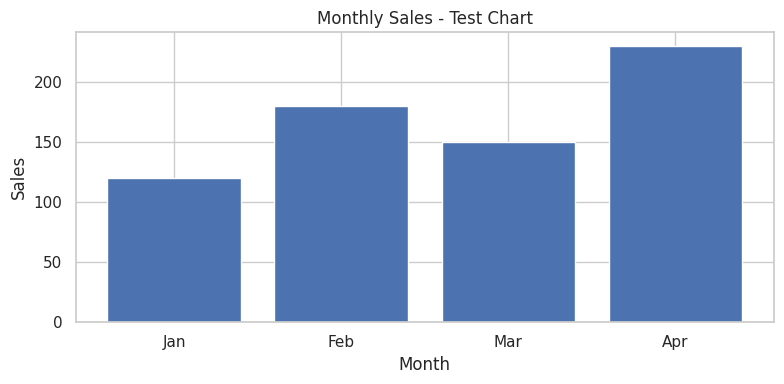

PNG chart created successfully!


In [64]:


import os
import matplotlib.pyplot as plt

os.makedirs("visualizations", exist_ok=True)

plt.figure(figsize=(8, 4))
plt.bar(["Jan", "Feb", "Mar", "Apr"], [120, 180, 150, 230])
plt.title("Monthly Sales - Test Chart")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()

plt.savefig("visualizations/monthly_sales_test.png", dpi=300)
plt.show()

print("PNG chart created successfully!")



In [65]:

from google.colab import files
files.download("visualizations/monthly_sales_test.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Using dataframe: df_original


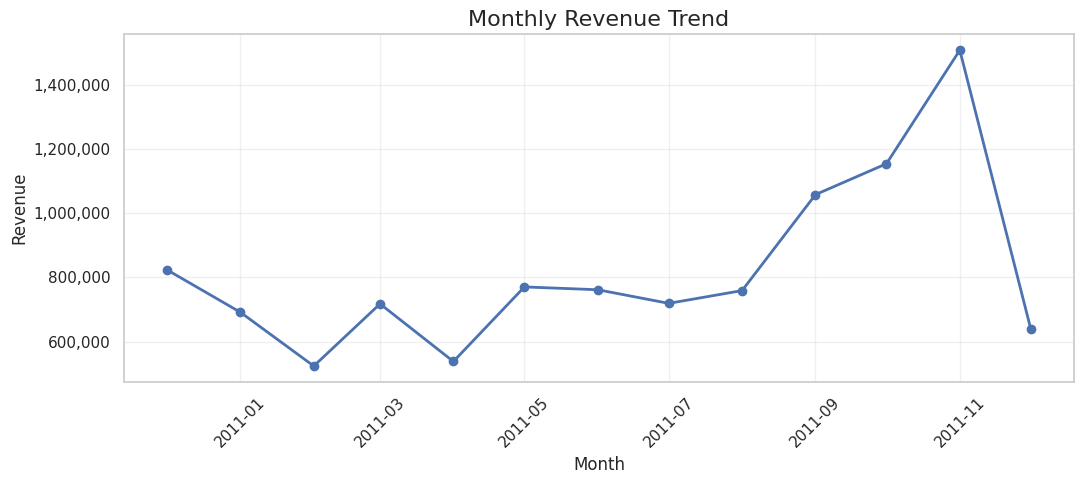

Saved: 01_monthly_sales_trend.png


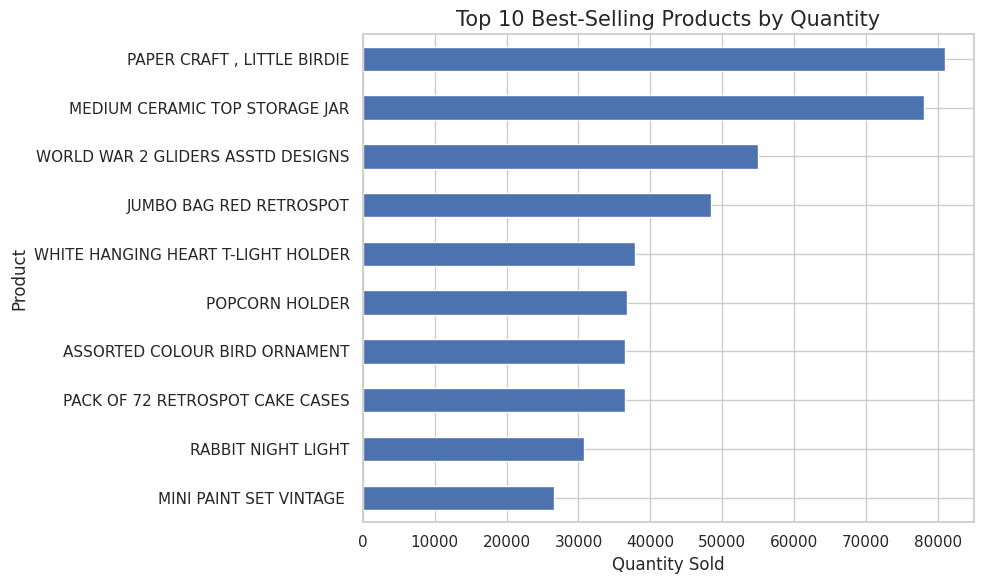

Saved: 02_top_10_products.png


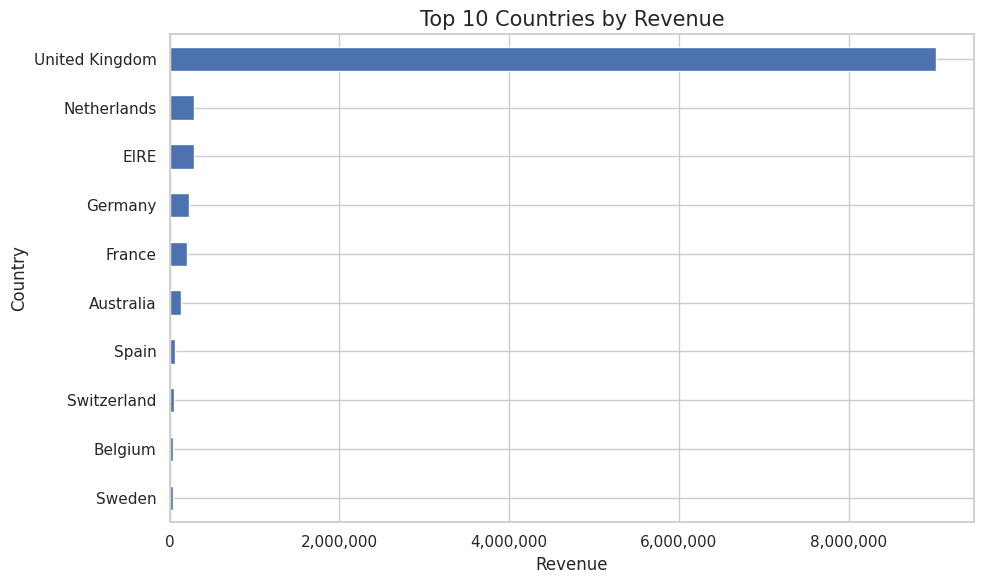

Saved: 03_top_10_countries.png


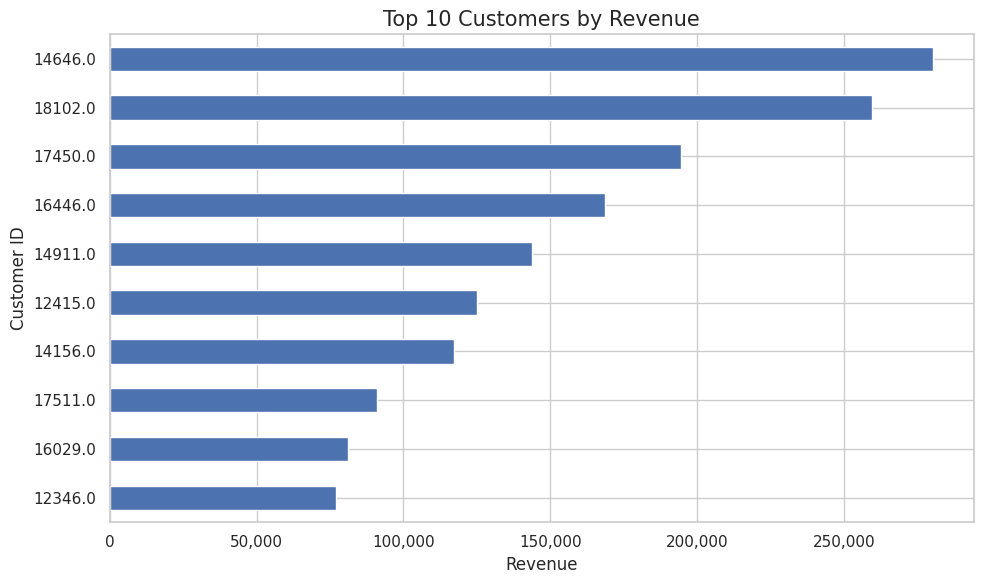

Saved: 04_top_10_customers.png


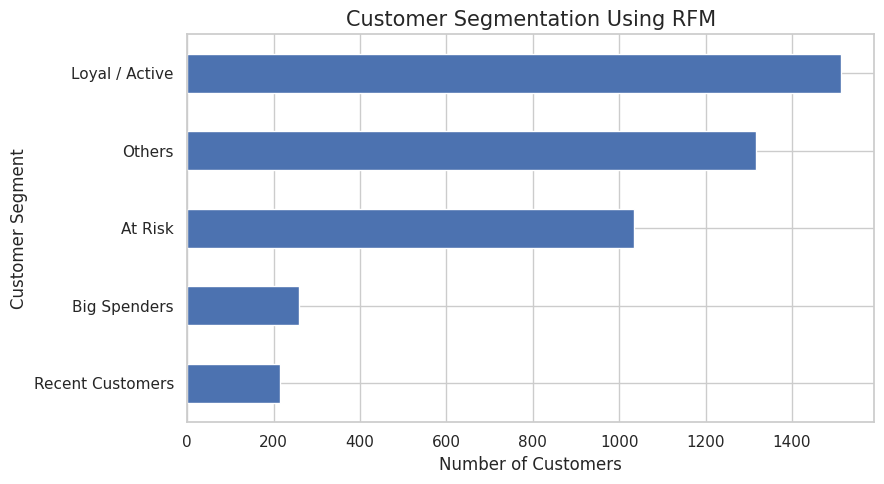

Saved: 05_customer_segments.png

All charts and the RFM CSV have been created!
Files saved in: /content/visualizations
Number of sales records used: 530104
Number of customers analyzed: 4338


In [66]:

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --------------------------------------------------
# 1. Find your cleaned retail dataset automatically
# --------------------------------------------------
required_columns = {
    "InvoiceDate", "Quantity", "UnitPrice",
    "Country", "Description", "CustomerID"
}

data = None

for variable_name, variable_value in list(globals().items()):
    if isinstance(variable_value, pd.DataFrame):
        if required_columns.issubset(set(variable_value.columns)):
            data = variable_value.copy()
            print(f"Using dataframe: {variable_name}")
            break

if data is None:
    raise ValueError(
        "Could not automatically find your cleaned dataset. "
        "Check your dataframe name and column names."
    )

# Ensure correct data types and valid sales rows
data["InvoiceDate"] = pd.to_datetime(
    data["InvoiceDate"], errors="coerce"
)
data["Quantity"] = pd.to_numeric(
    data["Quantity"], errors="coerce"
)
data["UnitPrice"] = pd.to_numeric(
    data["UnitPrice"], errors="coerce"
)

data = data.dropna(
    subset=["InvoiceDate", "Quantity", "UnitPrice"]
).copy()

# Exclude returns, cancelled invoices and invalid prices
data = data[
    (data["Quantity"] > 0) &
    (data["UnitPrice"] > 0) &
    (~data["InvoiceNo"].astype(str).str.startswith("C")
     if "InvoiceNo" in data.columns else True)
].copy()

data["Revenue"] = data["Quantity"] * data["UnitPrice"]

# Create output folder
output_folder = "visualizations"
os.makedirs(output_folder, exist_ok=True)

def save_chart(filename):
    plt.tight_layout()
    plt.savefig(
        os.path.join(output_folder, filename),
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()
    plt.close()
    print(f"Saved: {filename}")

# --------------------------------------------------
# Chart 1: Monthly Sales Trend
# --------------------------------------------------
monthly_sales = (
    data.set_index("InvoiceDate")["Revenue"]
    .resample("MS").sum()
)

plt.figure(figsize=(11, 5))
plt.plot(
    monthly_sales.index, monthly_sales.values,
    marker="o", linewidth=2
)
plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
save_chart("01_monthly_sales_trend.png")

# --------------------------------------------------
# Chart 2: Top 10 Products by Quantity Sold
# --------------------------------------------------
top_products = (
    data.groupby("Description")["Quantity"]
    .sum()
    .nlargest(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
top_products.plot(kind="barh")
plt.title("Top 10 Best-Selling Products by Quantity", fontsize=15)
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
save_chart("02_top_10_products.png")

# --------------------------------------------------
# Chart 3: Top 10 Countries by Revenue
# --------------------------------------------------
top_countries = (
    data.groupby("Country")["Revenue"]
    .sum()
    .nlargest(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
top_countries.plot(kind="barh")
plt.title("Top 10 Countries by Revenue", fontsize=15)
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.gca().xaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)
save_chart("03_top_10_countries.png")

# --------------------------------------------------
# Chart 4: Top 10 Customers by Revenue
# --------------------------------------------------
customer_data = data.dropna(subset=["CustomerID"]).copy()
customer_data["CustomerID"] = (
    customer_data["CustomerID"].astype(str)
)

top_customers = (
    customer_data.groupby("CustomerID")["Revenue"]
    .sum()
    .nlargest(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
top_customers.plot(kind="barh")
plt.title("Top 10 Customers by Revenue", fontsize=15)
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.gca().xaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)
save_chart("04_top_10_customers.png")

# --------------------------------------------------
# Chart 5: RFM Customer Segments
# --------------------------------------------------
snapshot_date = (
    customer_data["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

rfm = customer_data.groupby("CustomerID").agg(
    Recency=("InvoiceDate",
             lambda dates: (snapshot_date - dates.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
)

# Create quartile-based scores; handle tied values safely
rfm["R_score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    4, labels=[4, 3, 2, 1]
).astype(int)

rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4, labels=[1, 2, 3, 4]
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    4, labels=[1, 2, 3, 4]
).astype(int)

def assign_segment(row):
    if row["R_score"] >= 3 and row["F_score"] >= 3:
        return "Loyal / Active"
    elif row["M_score"] == 4:
        return "Big Spenders"
    elif row["R_score"] == 4:
        return "Recent Customers"
    elif row["R_score"] == 1:
        return "At Risk"
    else:
        return "Others"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)
segment_counts = rfm["Segment"].value_counts().sort_values()

plt.figure(figsize=(9, 5))
segment_counts.plot(kind="barh")
plt.title("Customer Segmentation Using RFM", fontsize=15)
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
save_chart("05_customer_segments.png")

# Save RFM results too, for your analysis folder
rfm.to_csv(
    os.path.join(output_folder, "customer_rfm_segments.csv")
)

print("\nAll charts and the RFM CSV have been created!")
print("Files saved in:", os.path.abspath(output_folder))
print("Number of sales records used:", len(data))
print("Number of customers analyzed:", rfm.shape[0])


In [67]:

from google.colab import files
import shutil

shutil.make_archive("retail_visualizations", "zip", "visualizations")
files.download("retail_visualizations.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:

# Verify that the cleaned dataframe is named data
data["Revenue"] = data["Quantity"] * data["UnitPrice"]

sales = data[
    (data["Quantity"] > 0) &
    (data["UnitPrice"] > 0)
].copy()

if "InvoiceNo" in sales.columns:
    sales = sales[
        ~sales["InvoiceNo"].astype(str).str.startswith("C")
    ]

sales["Revenue"] = sales["Quantity"] * sales["UnitPrice"]
sales["InvoiceDate"] = pd.to_datetime(sales["InvoiceDate"])

print("Total Revenue:", round(sales["Revenue"].sum(), 2))

monthly = sales.groupby(
    sales["InvoiceDate"].dt.to_period("M")
)["Revenue"].sum()
print("Best Month:", monthly.idxmax(), "Revenue:", round(monthly.max(), 2))

print("Top Country:")
print(sales.groupby("Country")["Revenue"].sum().idxmax())

print("Best-Selling Product:")
print(sales.groupby("Description")["Quantity"].sum().idxmax())

print("Unique Customers:", sales["CustomerID"].nunique())


Total Revenue: 10666684.54
Best Month: 2011-11 Revenue: 1509496.33
Top Country:
United Kingdom
Best-Selling Product:
PAPER CRAFT , LITTLE BIRDIE
Unique Customers: 4338


In [69]:


import os
import zipfile
from google.colab import files

zip_path = "/content/All_Visualizations.zip"

image_files = [
    f for f in os.listdir(VISUALIZATION_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Total charts saved:", len(image_files))

if image_files:
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
        for filename in image_files:
            zipf.write(
                os.path.join(VISUALIZATION_DIR, filename),
                arcname=filename
            )

    files.download(zip_path)
else:
    print("No charts found. Check whether your plotting cells use plt.show().")



Total charts saved: 23


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:

from google.colab import files
import zipfile
import os

# Upload the ZIP file you downloaded
uploaded = files.upload()

zip_name = next(iter(uploaded))

# Extract all images
with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall("/content/All_Visualizations_Renamed")

print("Images extracted successfully!")
print(os.listdir("/content/All_Visualizations_Renamed"))


Saving All_Visualizations_Renamed.zip to All_Visualizations_Renamed.zip
Images extracted successfully!
['19_monthly_revenue_trend_alternate.png', '22_top_10_customers_by_revenue_alternate.png', '07_monthly_revenue_trend.png', '04_top_10_products_by_quantity.png', '09_order_lines_by_hour.png', '18_monthly_sales_test_chart_review_before_submission.png', '15_cancelled_vs_non_cancelled_lines.png', '06_revenue_share_by_country.png', '23_customer_segmentation_rfm_alternate.png', '01_missing_values_by_column.png', '20_top_10_products_by_quantity_alternate.png', '05_top_10_countries_by_revenue.png', '12_quantity_and_unit_price_boxplots.png', '17_revenue_by_rfm_segment.png', '02_quantity_and_unit_price_distributions.png', '11_top_10_customers_by_revenue.png', '16_customer_count_by_rfm_segment.png', '03_top_10_products_by_revenue.png', '08_orders_by_weekday.png', '13_quantity_vs_unit_price_scatter.png', '10_line_revenue_distribution.png', '14_quantity_unit_price_revenue_correlation_heatmap.png',

## 1. Key Findings

- Total revenue was approximately £10.67 million.
- November 2011 was the highest-revenue month.
- The United Kingdom generated the highest revenue.
- `PAPER CRAFT , LITTLE BIRDIE` was the best-selling product by quantity.
- The analysis identified 4,338 unique customers.
- RFM segmentation helped categorize customers based on purchasing behavior.

## 2. Business Recommendations

- Prepare inventory and marketing campaigns ahead of peak sales periods.
- Monitor popular products to reduce stock shortages.
- Develop targeted retention campaigns for valuable and at-risk customers.
- Investigate cancelled orders and unusual transactions to identify improvement opportunities.

## 3. Limitations

- The dataset covers a historical period from December 2010 to December 2011.
- Missing customer IDs limit customer-level analysis for some transactions.
- Historical sales trends may not reflect current customer behavior.
- RFM results depend on the scoring method and segmentation thresholds used.